## Airbnb Professionalization Analysis

*Data Visualizations 2026 — Project*

In this notebook we explore two Airbnb datasets — Rome and Copenhagen — downloaded from [Inside Airbnb](https://insideairbnb.com/get-the-data/), an independent, non-commercial project that collects publicly available information from the Airbnb website.

The central question we are trying to answer is:

> *To what extent is Airbnb characterized by professionalized hosting rather than casual sharing, and how do patterns differ between Rome and Copenhagen?*

We proceed in four steps: loading and inspecting the data, cleaning it, engineering the features we need for the analysis, and finally producing a set of visualizations.

In [6]:
import logging
import sys

formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(formatter)

logger = logging.getLogger('airbnb_notebook')
logger.setLevel(logging.INFO)
logger.addHandler(handler)

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

### Using pathlib avoids hardcoded paths and works across operating systems.
### Place your CSV files in a subfolder called 'data'.

#base_path = Path("data")

rome_df = pd.read_csv("/Users/andreamammano/Data Visualization/DataVisualisationPW_MESA/data/rome/listings.csv", low_memory=False)
cph_df  = pd.read_csv("/Users/andreamammano/Data Visualization/DataVisualisationPW_MESA/data/copenhagen/listings.csv", low_memory=False)

rome_df["city"] = "Rome"
cph_df["city"]  = "Copenhagen"

logger.info(f"Rome loaded: {len(rome_df):,} rows, {rome_df.shape[1]} columns")
logger.info(f"Copenhagen loaded: {len(cph_df):,} rows, {cph_df.shape[1]} columns")

2026-03-26 16:58:35,321 - INFO - Rome loaded: 37,652 rows, 80 columns
2026-03-26 16:58:35,321 - INFO - Rome loaded: 37,652 rows, 80 columns
2026-03-26 16:58:35,322 - INFO - Copenhagen loaded: 22,994 rows, 80 columns
2026-03-26 16:58:35,322 - INFO - Copenhagen loaded: 22,994 rows, 80 columns


## Inspecting the data

Before doing anything else, it's good practice to look at what we actually have. Inside Airbnb's `listings.csv` contains over 70 columns, most of which we don't need. We select only the fields relevant to our analysis.

In [8]:
from IPython.display import display

display(rome_df.head())

#rome_df.shape
#rome_df.info()
#rome_df.columns
#rome_df.describe()
#rome_df['room_type'].value_counts()
#rome_df['room_type'].value_counts(normalize=True)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,2737,https://www.airbnb.com/rooms/2737,20250914152919,2025-09-15,city scrape,"Elif's room in cozy, clean flat.",10 min by bus you can get to Piazza Venezia or...,It used to be an industrial area until late 80...,https://a0.muscache.com/pictures/41225252/e955...,3047,...,4.40,4.40,NaN,f,6,0,6,0,0.04,Rome
1,11834,https://www.airbnb.com/rooms/11834,20250914152919,2025-09-15,city scrape,"Charming Boschetto Studio, Rome",Fantastic apartment in the Monti district. The...,"""Monti"" with its narrow cobblestone alleys, cr...",https://a0.muscache.com/pictures/miso/Hosting-...,44552,...,4.99,4.81,IT058091C29VJSIZQZ,f,1,1,0,0,1.62,Rome
2,12398,https://www.airbnb.com/rooms/12398,20250914152919,2025-09-15,city scrape,Casa Donatello - Home far from Home,Casa Donatello is a newly renovated two-bedroo...,You are at 15 minutes walking distance from hi...,https://a0.muscache.com/pictures/miso/Hosting-...,11756,...,4.89,4.83,it058091c2kv6epw8f,f,1,1,0,0,0.47,Rome
3,19965,https://www.airbnb.com/rooms/19965,20250914152919,2025-09-15,city scrape,S. Peter's Square 5 Min WALK bright and quite ...,AT ONLY 5 MINUTES WALK to S.Peter's Basilica S...,Prati is a famous neighbourhood (rione of Rome...,https://a0.muscache.com/pictures/hosting/Hosti...,75450,...,4.90,4.54,IT058091C20YD35BX2,t,3,3,0,0,1.07,Rome
4,19967,https://www.airbnb.com/rooms/19967,20250914152919,2025-09-15,city scrape,*In front Vatican Museums 2 bedrooms quite bri...,"IN FRONT of the Vatican Museums entrance, at O...",Prati is a famous neighbourhood (rione of Rome...,https://a0.muscache.com/pictures/hosting/Hosti...,75450,...,4.85,4.28,IT058091C20YD35BX2,t,3,3,0,0,0.32,Rome


In [9]:
COLS = [
    "id", "city",
    "host_id", "host_name", "host_since",
    "host_is_superhost",
    "host_listings_count",
    "calculated_host_listings_count",  ## more reliable than host_listings_count
    "neighbourhood_cleansed",
    "latitude", "longitude",
    "room_type",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "last_review",
]

### Keep only columns that exist in both datasets
common_cols = [c for c in COLS if c in rome_df.columns and c in cph_df.columns]

rome_df = rome_df[common_cols].copy()
cph_df  = cph_df[common_cols].copy()

df = pd.concat([rome_df, cph_df], ignore_index=True)

logger.info(f"Combined dataset: {len(df):,} rows")

2026-03-26 16:58:35,378 - INFO - Combined dataset: 60,646 rows
2026-03-26 16:58:35,378 - INFO - Combined dataset: 60,646 rows


## Cleaning

A few things need attention before we can do any meaningful analysis.

1. **Price** comes in as a string formatted like `$1,234.00` — we strip the symbols and convert to float.
2. **Missing values** are handled differently for numerical and categorical columns, following the same logic seen in the penguins notebook.
3. We remove listings with clearly erroneous prices (below $5 or above $2000).

In [10]:
missing_table = df.isnull().sum()
print(missing_table[missing_table > 0])

host_name                 22
host_since                23
host_is_superhost       2395
host_listings_count       23
price                  13640
reviews_per_month       7768
last_review             7768
dtype: int64


In [11]:
### Price cleaning: strip currency symbols, convert to float

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
    .replace("", np.nan)
    .astype(float)
)

n_before = len(df)
df = df[(df["price"] >= 5) & (df["price"] <= 2000)]
logger.info(f"Removed {n_before - len(df)} listings with anomalous price")

2026-03-26 16:58:35,418 - INFO - Removed 15796 listings with anomalous price
2026-03-26 16:58:35,418 - INFO - Removed 15796 listings with anomalous price


In [12]:
numerical_columns   = df.select_dtypes(include=["float", "int"]).columns
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

## reviews_per_month is NaN when a listing has no reviews — fill with 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

## use calculated_host_listings_count where available — it's more reliable
if "calculated_host_listings_count" in df.columns:
    df["host_listings_count"] = df["calculated_host_listings_count"].fillna(
        df["host_listings_count"]
    )

df["host_listings_count"] = df["host_listings_count"].fillna(1).astype(int)

## host_is_superhost is stored as 't'/'f' strings
df["host_is_superhost"] = df["host_is_superhost"].map({"t": True, "f": False})

n_dupes = df.duplicated(subset=["id", "city"]).sum()
df = df.drop_duplicates(subset=["id", "city"])
logger.info(f"Removed {n_dupes} duplicate rows")

2026-03-26 16:58:35,430 - INFO - Removed 0 duplicate rows
2026-03-26 16:58:35,430 - INFO - Removed 0 duplicate rows


/var/folders/c9/_fv78__x2mld68ft6pqwr2880000gn/T/ipykernel_60289/1941977081.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object", "category"]).columns


## Feature Engineering

The most important derived variable is the **host segment**. We classify each host as *Casual*, *Semi-Pro*, or *Professional* based on how many listings they manage. The threshold is somewhat arbitrary — a common choice in the literature is 2 listings for Semi-Pro and 5+ for Professional, but this is exactly what our JavaScript simulator will let the user explore interactively.

We also compute an **estimated monthly revenue**, following the methodology used by Inside Airbnb themselves. It is important to flag this clearly: this is a *model estimate*, not real earnings data. Inside Airbnb assumes a 72% occupancy rate, which is generous and likely inflates numbers for casual hosts.

In [13]:
def segment_host(n, threshold_semi=2, threshold_pro=5):
    if n < threshold_semi:
        return "Casual"
    elif n <= threshold_pro:
        return "Semi-Pro"
    else:
        return "Professional"

df["host_segment"] = df["host_listings_count"].apply(segment_host)

#df["host_segment"].value_counts()
#df["host_segment"].value_counts(normalize=True)

In [14]:
### Revenue estimate — Inside Airbnb methodology
### price × minimum_nights × reviews_per_month × occupancy_factor
### NOTE: this is a rough proxy, not actual earnings data — declare this in the paper

OCCUPANCY_FACTOR = 0.72

df["estimated_monthly_revenue"] = (
    df["price"] * df["minimum_nights"] * df["reviews_per_month"] * OCCUPANCY_FACTOR
).clip(upper=50_000)

## flag listings that look more commercial than residential
df["likely_commercial"] = (
    (df["availability_365"] > 180) & (df["reviews_per_month"] > 1)
).astype(int)

## Exploratory Analysis

Now that the data is clean, we can start looking at the distributions. The key question is: how concentrated is the market? If Airbnb were truly a sharing economy platform, we would expect most hosts to have exactly one listing. What we actually observe is a long right tail — a small number of hosts controlling a disproportionate share of the market.

In [15]:
summary = df.groupby("city").agg(
    total_listings        = ("id", "count"),
    unique_hosts          = ("host_id", "nunique"),
    avg_listings_per_host = ("host_listings_count", "mean"),
    median_price          = ("price", "median"),
    pct_professional      = ("host_segment", lambda x: (x == "Professional").mean() * 100),
    pct_casual            = ("host_segment", lambda x: (x == "Casual").mean() * 100),
).round(2)

display(summary.T)

city,Copenhagen,Rome
total_listings,11442.00,33408.00
unique_hosts,10405.00,18630.00
avg_listings_per_host,5.45,9.56
median_price,1100.00,132.00
pct_professional,6.01,26.61
pct_casual,85.14,40.52


## Visualizations

We use `seaborn` for all static visualizations. Following the approach seen in the labs, we define the theme once globally and then build each figure using `fig, ax = plt.subplots()`.

Figures 4 and 5 are the **white hat / black hat** pair — they use the same underlying data but make deliberately different choices (median vs mean) to show how summary statistics can be used to tell very different stories.

In [16]:
sns.set_theme(
    style="white",
    font="Optima",
    palette="pastel"
)

PALETTE     = {"Casual": "#4C9BE8", "Semi-Pro": "#F5A623", "Professional": "#E84C4C"}
CITY_COLORS = {"Rome": "#E84C4C", "Copenhagen": "#4C9BE8"}

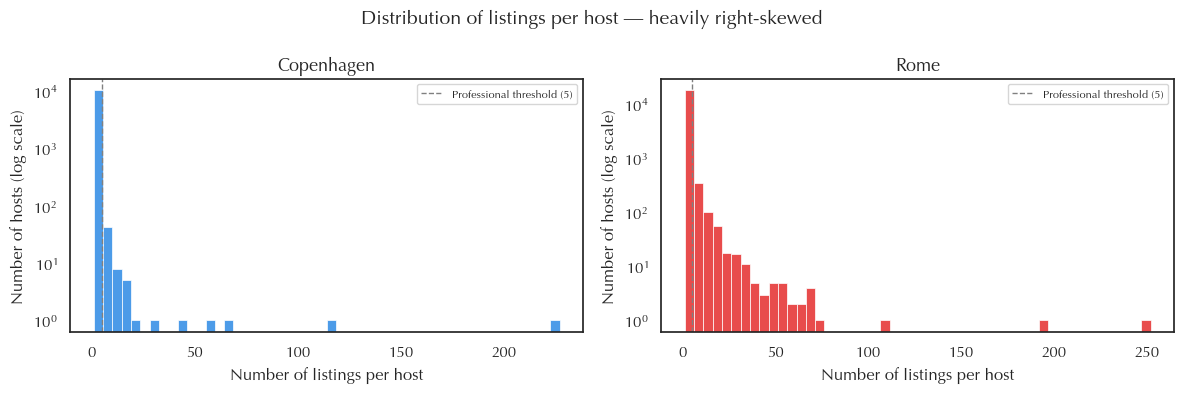

In [ ]:
### Fig 1 — Distribution of listings per host (log scale)
### A log scale is necessary here because the distribution is heavily right-skewed.

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, (city, group) in zip(axes, df.groupby("city")):
    host_counts = group.groupby("host_id")["host_listings_count"].first()
    ax.hist(host_counts, bins=50, color=CITY_COLORS[city], edgecolor="white", linewidth=0.5)
    ax.set_yscale("log")
    ax.set_title(city, fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of listings per host")
    ax.set_ylabel("Number of hosts (log scale)")
    ax.axvline(5, color="gray", linestyle="--", linewidth=1, label="Professional threshold (5)")
    ax.legend(fontsize=8)

fig.suptitle("Distribution of listings per host — heavily right-skewed", fontsize=14)
plt.tight_layout()
#plt.savefig("fig1_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

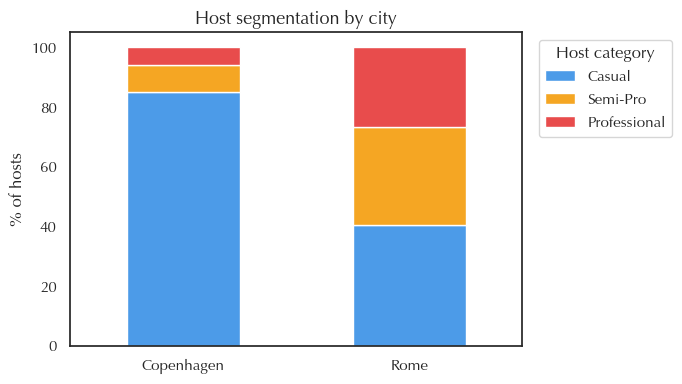

In [ ]:
### Fig 2 — Host segmentation by city (stacked bar)

seg_pct = (
    df.groupby(["city", "host_segment"])
    .size()
    .div(df.groupby("city").size(), level="city")
    .mul(100)
    .unstack("host_segment")
    .reindex(columns=["Casual", "Semi-Pro", "Professional"])
)

fig, ax = plt.subplots(figsize=(7, 4))

seg_pct.plot(
    kind="bar",
    stacked=True,
    color=list(PALETTE.values()),
    ax=ax,
    edgecolor="white"
)

ax.set_xlabel("")
ax.set_ylabel("% of hosts")
ax.set_title("Host segmentation by city", fontsize=13, fontweight="bold")
ax.legend(title="Host category", bbox_to_anchor=(1.02, 1))
ax.set_xticklabels(seg_pct.index, rotation=0)

plt.tight_layout()
#plt.savefig("fig2_segments.png", bbox_inches="tight", dpi=150)
plt.show()

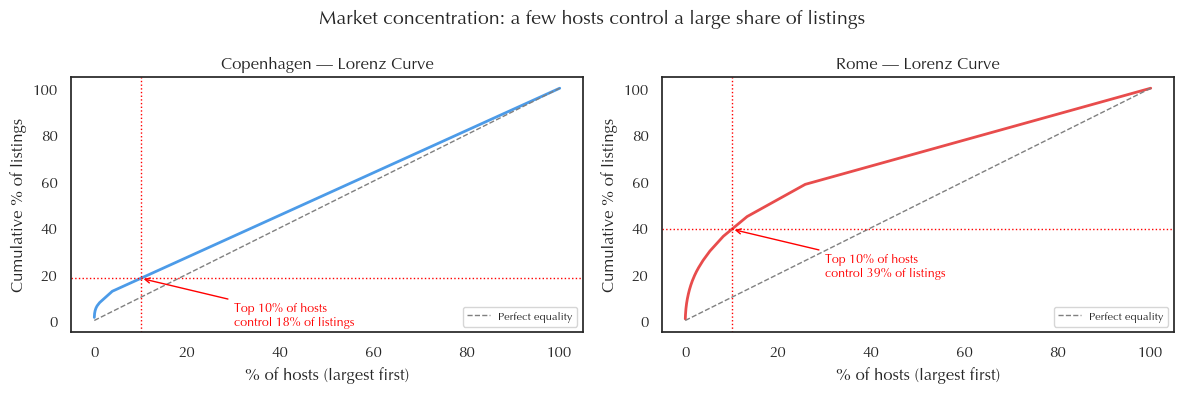

In [ ]:
### Fig 3 — Lorenz curve (market concentration)
### The Lorenz curve shows how far a distribution is from perfect equality.
### A perfectly equal market would follow the diagonal.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (city, group) in zip(axes, df.groupby("city")):

    host_listings = (
        group.groupby("host_id")["id"]
        .count()
        .sort_values(ascending=False)
        .reset_index()
    )
    host_listings["cumulative_share"] = (
        host_listings["id"].cumsum() / host_listings["id"].sum() * 100
    )
    host_listings["host_rank_pct"] = (
        np.arange(1, len(host_listings) + 1) / len(host_listings) * 100
    )

    ax.plot(
        host_listings["host_rank_pct"],
        host_listings["cumulative_share"],
        color=CITY_COLORS[city], linewidth=2
    )
    ax.plot([0, 100], [0, 100], color="gray", linestyle="--", linewidth=1, label="Perfect equality")

    top10 = host_listings[host_listings["host_rank_pct"] <= 10]["cumulative_share"].max()
    ax.axvline(10, color="red", linestyle=":", linewidth=1)
    ax.axhline(top10, color="red", linestyle=":", linewidth=1)
    ax.annotate(
        f"Top 10% of hosts\ncontrol {top10:.0f}% of listings",
        xy=(10, top10), xytext=(30, top10 - 20),
        arrowprops=dict(arrowstyle="->", color="red"),
        fontsize=9, color="red"
    )

    ax.set_title(f"{city} — Lorenz Curve", fontsize=12, fontweight="bold")
    ax.set_xlabel("% of hosts (largest first)")
    ax.set_ylabel("Cumulative % of listings")
    ax.legend(fontsize=8)

fig.suptitle("Market concentration: a few hosts control a large share of listings", fontsize=14)
plt.tight_layout()
#plt.savefig("fig3_lorenz.png", bbox_inches="tight", dpi=150)
plt.show()

## White Hat / Black Hat

The following two figures use the *same data* but present it in two different ways.

**White hat (Fig 4):** We use the *median* revenue, which gives a representative picture of what a typical host in each segment actually earns. The median is robust to outliers.

**Black hat (Fig 5):** We use the *mean* revenue instead. Because the distribution is extremely right-skewed — a handful of professional hosts earn enormous amounts — the mean is pulled upward significantly. This creates the misleading impression that hosting is highly lucrative across the board, which could be used to argue against regulation or to attract new hosts under false expectations.

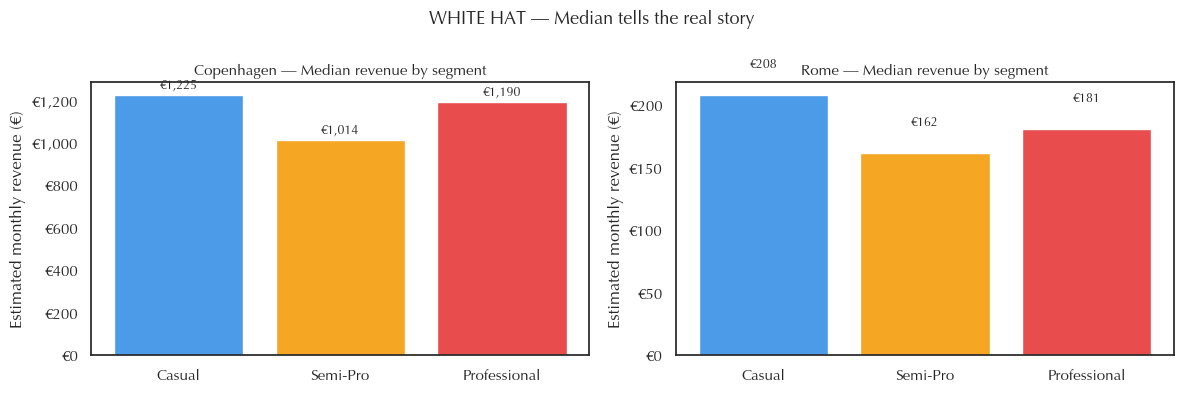

In [ ]:
### Fig 4 — WHITE HAT: median revenue per segment

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (city, group) in zip(axes, df.groupby("city")):
    med_rev = group.groupby("host_segment")["estimated_monthly_revenue"].median().reindex(
        ["Casual", "Semi-Pro", "Professional"]
    )
    bars = ax.bar(
        med_rev.index, med_rev.values,
        color=[PALETTE[s] for s in med_rev.index], edgecolor="white"
    )
    ax.set_title(f"{city} — Median revenue by segment", fontsize=11, fontweight="bold")
    ax.set_ylabel("Estimated monthly revenue (€)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
    for bar, val in zip(bars, med_rev.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"€{val:,.0f}", ha="center", va="bottom", fontsize=9
        )

fig.suptitle("WHITE HAT — Median tells the real story", fontsize=13)
plt.tight_layout()
#plt.savefig("fig4_whitehat.png", bbox_inches="tight", dpi=150)
plt.show()

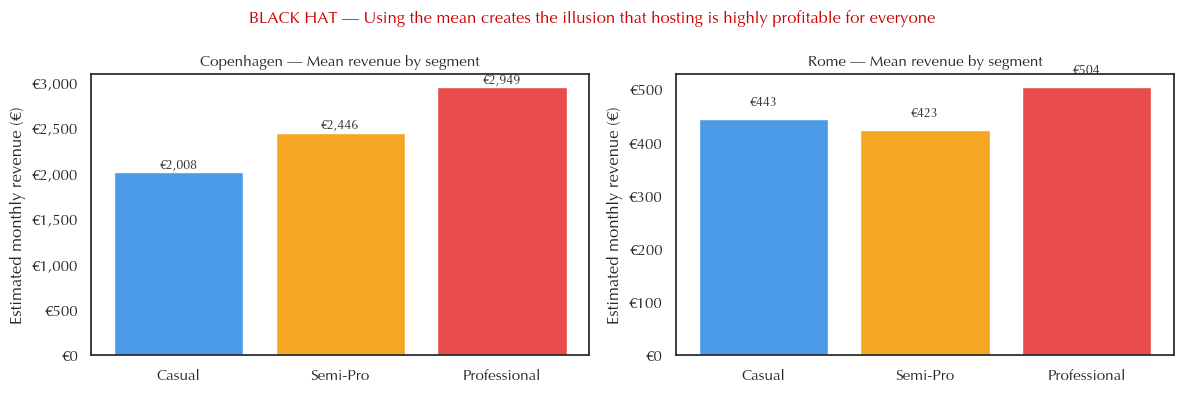

In [ ]:
### Fig 5 — BLACK HAT: mean revenue per segment
### The mean is inflated by outlier hosts — it creates a misleading picture

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (city, group) in zip(axes, df.groupby("city")):
    mean_rev = group.groupby("host_segment")["estimated_monthly_revenue"].mean().reindex(
        ["Casual", "Semi-Pro", "Professional"]
    )
    bars = ax.bar(
        mean_rev.index, mean_rev.values,
        color=[PALETTE[s] for s in mean_rev.index], edgecolor="white"
    )
    ax.set_title(f"{city} — Mean revenue by segment", fontsize=11, fontweight="bold")
    ax.set_ylabel("Estimated monthly revenue (€)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
    for bar, val in zip(bars, mean_rev.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"€{val:,.0f}", ha="center", va="bottom", fontsize=9
        )

fig.suptitle(
    "BLACK HAT — Using the mean creates the illusion that hosting is highly profitable for everyone",
    fontsize=12, color="#cc0000"
)
plt.tight_layout()
#plt.savefig("fig5_blackhat.png", bbox_inches="tight", dpi=150)
plt.show()

## Export for Tableau

We export two CSV files. The first is the full cleaned dataset, which can be loaded directly into Tableau. The second aggregates data at the host level and is useful for scatter plots and concentration analysis.

In [22]:
df.to_csv("airbnb_clean_combined.csv", index=False)
logger.info(f"Exported: airbnb_clean_combined.csv ({len(df):,} rows)")

host_agg = (
    df.groupby(["host_id", "city"])
    .agg(
        host_name         = ("host_name", "first"),
        host_segment      = ("host_segment", "first"),
        n_listings        = ("id", "count"),
        avg_price         = ("price", "mean"),
        total_est_revenue = ("estimated_monthly_revenue", "sum"),
        avg_availability  = ("availability_365", "mean"),
        n_reviews         = ("number_of_reviews", "sum"),
    )
    .round(2)
    .reset_index()
)

host_agg.to_csv("airbnb_host_aggregated.csv", index=False)
logger.info(f"Exported: airbnb_host_aggregated.csv ({len(host_agg):,} unique hosts)")

2026-03-26 16:58:36,555 - INFO - Exported: airbnb_clean_combined.csv (44,850 rows)
2026-03-26 16:58:36,555 - INFO - Exported: airbnb_clean_combined.csv (44,850 rows)
2026-03-26 16:58:36,611 - INFO - Exported: airbnb_host_aggregated.csv (29,035 unique hosts)
2026-03-26 16:58:36,611 - INFO - Exported: airbnb_host_aggregated.csv (29,035 unique hosts)
